# MODUL 3 - Perbaikan Citra dan Deteksi Tepi
------------------------------------------

In [278]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## Import Library

Bagian ini mengimpor tiga library dengan kegunaan masing-masing yaitu:
- **NumPy (`np`)** — untuk operasi array dan matriks piksel secara efisien
- **Matplotlib (`plt`)** — untuk menampilkan citra dan histogram secara visual
- **OpenCV (`cv`)** — untuk membaca, mengkonversi, dan memproses citra

In [279]:
def convolution(img, kernel):
    # ukuran kernel / kernel size
    size = kernel.shape[0]
    # ukuran padding / padding size
    pad_size = size // 2
    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)
    # dimensi gambar / image dimensions
    height, width = img.shape
    # loop baris / loop rows
    for i in range(height):
        # loop kolom / loop columns
        for j in range(width):
            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]
            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)
    # kembalikan gambar / return image
    return canvas
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

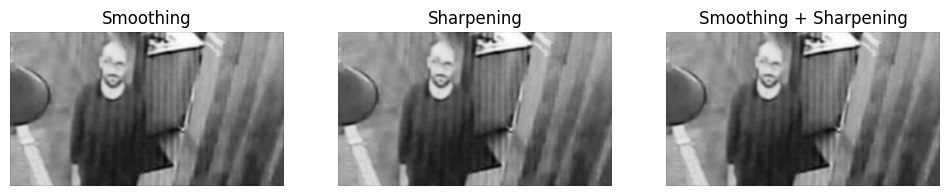

In [280]:
def tambah(citra1,citra2):
    return citra1+citra2

backup = cv.imread('backup.jpg')
backup = cv.cvtColor(backup,cv.COLOR_BGR2GRAY)

smoothing = convolution(backup,kernelSmoothing)
sharpening = convolution(backup,kernelSharpening)
smoothsharpening = tambah(smoothing,sharpening)

plt.figure(figsize=(12,6))
plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothsharpening, cmap='gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')


## Hasil Perbedaan Antara ke-3 Metode

- **Smoothing** — hasil dari citra yang sudah dilakukan smoothing, gambarnya jadi lebih halus akibat mengurangnya pixel yang terdapat pada gambar
- **Sharpening** — hasil dari citra yang sudah dilakukan sharpening, gambarnya jadi lebih tajam akibat menambahnya pixel yang terdapat pada gambar
- **Smoothing +  Sharpening** — untuk hasil citra pada metode ini pixel dalam gambar jadi lebih seimbang

In [281]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            # filter rata-rata / mean filter
            area = size * size
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus mean manual / manual mean formula
                    canvas[i, j] = np.sum(region) // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = np.sort(region.ravel())
                    mid = len(values) // 2
                    canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val

    # kembalikan gambar / return image
    return canvas

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

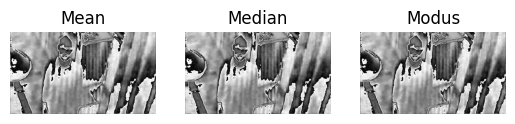

In [282]:
mean = filter(smoothsharpening,3,'mean')
median = filter(smoothsharpening,3,'median')
modus = filter(smoothsharpening,3,'modus')

plt.subplot(1,3,1)
plt.imshow(mean, cmap='gray')
plt.title('Mean')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(median, cmap='gray')
plt.title('Median')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(modus, cmap='gray')
plt.title('Modus')
plt.axis('off')

## Hasil Perbedaan Antara Mean,Median dan Modus

- **Mean** — hasil dari citra yang sudah dilakukan mean, pixel dalam citra dirombak ulang dan akan menggunakan matriks piksel yang sudah dirata-takan.
- **Median** — hasil dari citra yang sudah dilakukan median, pixel dalam citra dirombak ulang dan akan menggunakan matriks piksel yang sudah menggunakan array yang tengah.
- **Modus** — hasil dari citra yang sudah dilakukan modus, pixel dalam citra dirombak ulang dan akan menggunakan matriks piksel yang paling banyak muncul.

In [283]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [1, 0],
    [0, -1],
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

In [284]:
def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)
    # gabung gradien absolut / combine absolute gradients
    canvas = np.sqrt(gx**2 + gy**2)
    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

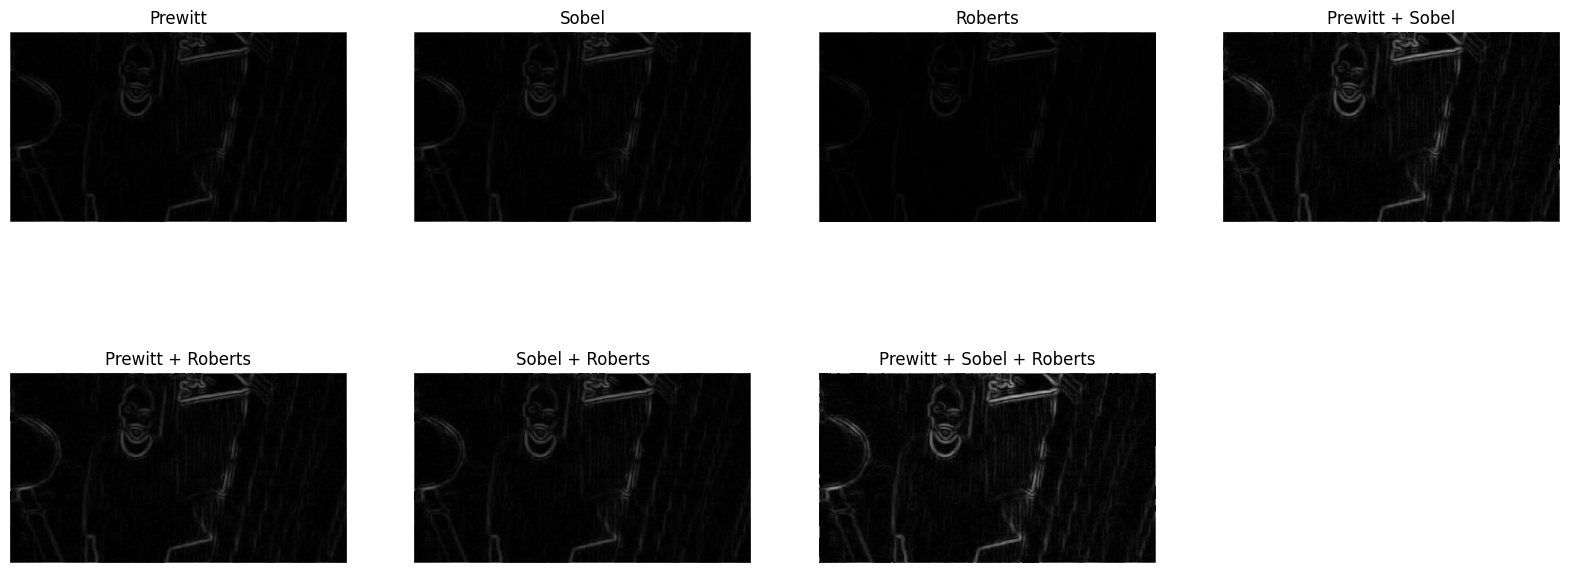

In [285]:
prewitt = edge(backup,prewittX,prewittY)
sobel = edge(backup,sobelX,sobelY)
roberts = edge(backup,robertsX,robertsY)
prewitt_sobel = tambah(prewitt,sobel)
prewitt_roberts = tambah(prewitt,roberts)
sobel_roberts = tambah(sobel,roberts)
prewitt_sobel_roberts = tambah(prewitt_sobel,roberts)

plt.figure(figsize=(20,17))
plt.subplot(4,4,1)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(4,4,2)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(4,4,3)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(4,4,4)
plt.imshow(prewitt_sobel, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(4,4,5)
plt.imshow(prewitt_roberts, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(4,4,6)
plt.imshow(sobel_roberts, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(4,4,7)
plt.imshow(prewitt_sobel_roberts, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')


## Kegunaan Operator dan Kombinasi Operator

Operator-operator yang digunakan untuk menghasilkan garis tepi yang ada pada citra, Roberts menghasilkan garis yang tipis, berbeda dengan Sobel yang sangat detail.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

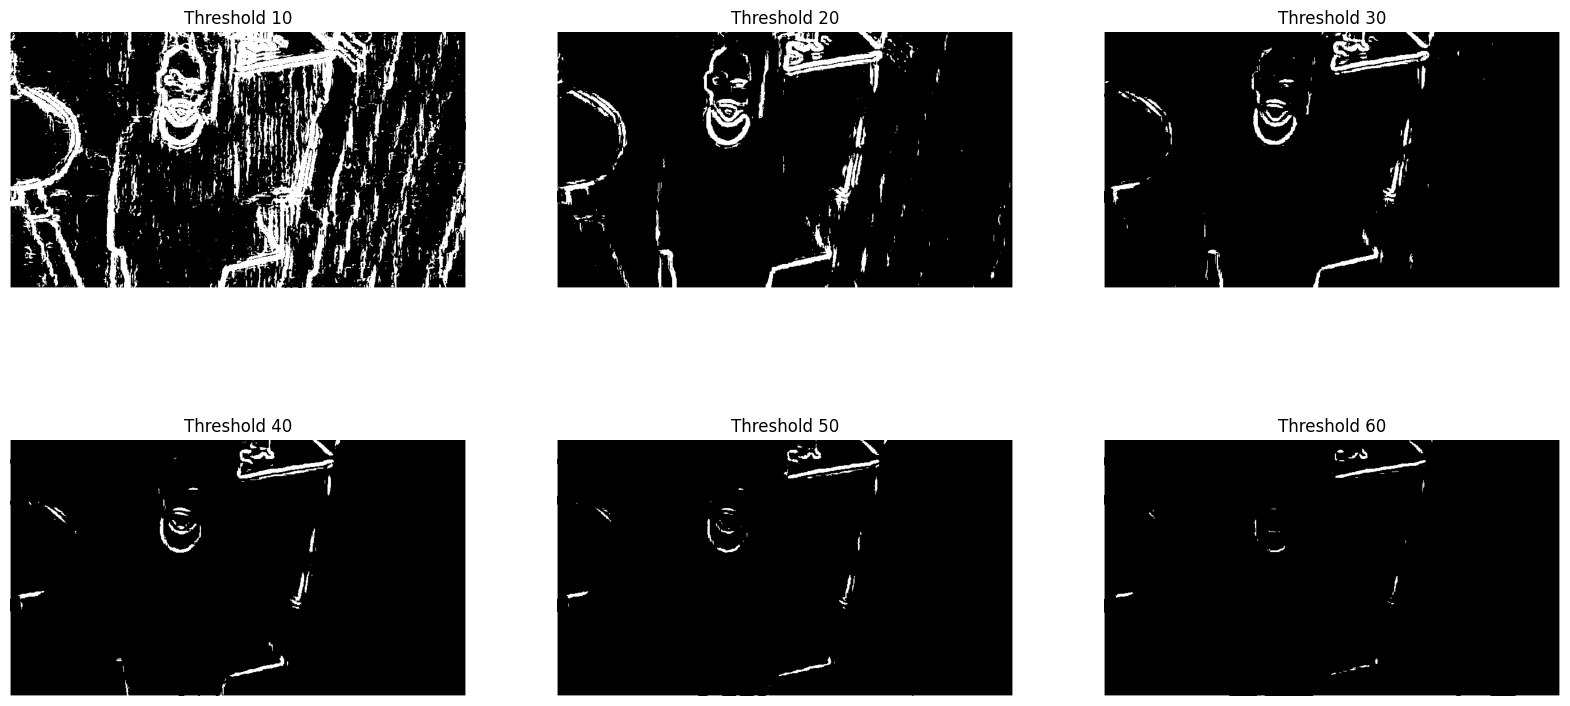

In [292]:
def threshold (img,th):
    return(img > th).astype(np.uint8)*255

th_10 = threshold(prewitt_sobel,10)
th_20 = threshold(prewitt_roberts,20)
th_30 = threshold(prewitt_roberts,30)
th_40 = threshold(prewitt_roberts,40)
th_50 = threshold(prewitt_roberts,50)
th_60 = threshold(prewitt_roberts,60)

plt.figure(figsize=(20,15))
plt.subplot(3,3,1)
plt.imshow(th_10, cmap='gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(th_20, cmap='gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(th_30, cmap='gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(th_40, cmap='gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(th_50, cmap='gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(th_60, cmap='gray')
plt.title('Threshold 60')
plt.axis('off')


(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

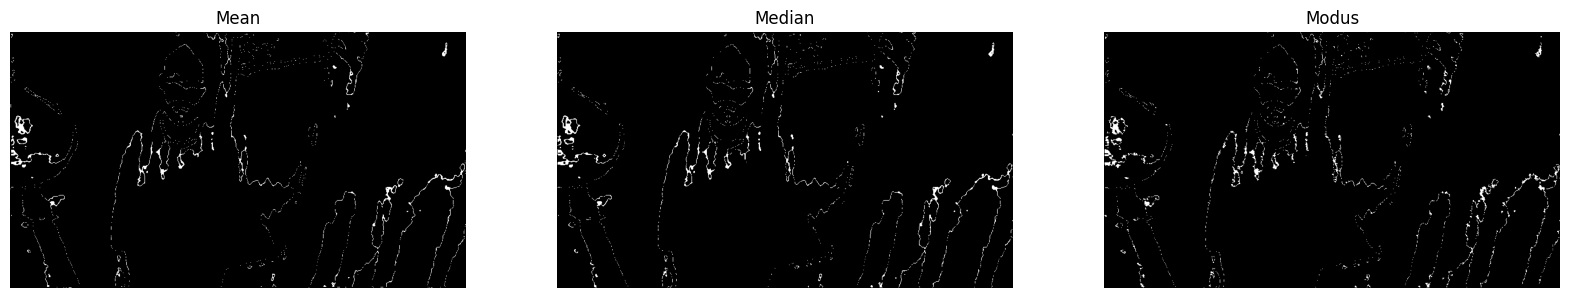

In [287]:
gambar1 = threshold(mean,250)
gambar2 = threshold(median,250)
gambar3 = threshold(modus,250)

plt.figure(figsize=(20,15))
plt.subplot(1,3,1)
plt.imshow(gambar1, cmap='gray')
plt.title('Mean')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gambar2, cmap='gray')
plt.title('Median')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gambar3, cmap='gray')
plt.title('Modus')
plt.axis('off')



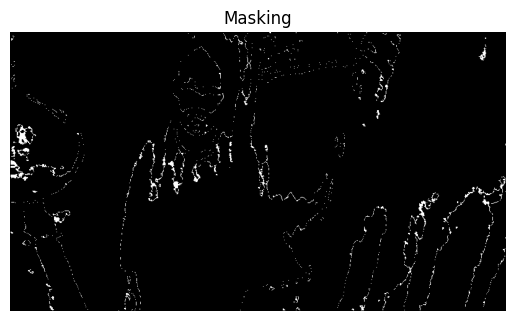

In [288]:
masking = []

height, width = gambar3.shape
image_matrix = gambar3

for y in range(height):
    row = []
    for x in range(width):
        if image_matrix[y][x] > 100:
            mask = 1
        else:
            mask = 0
        value = image_matrix[y][x] * mask
        row.append(value)
    masking.append(row)

plt.imshow(masking, cmap='gray')
plt.title('Masking')
plt.axis('off')
plt.show()

In [289]:
david = cv.imread('david.jpg')
